<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/23_MultiClass_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. 다중 분류

In [3]:
import pandas as pd
penguins = pd.read_csv('./penguins.csv')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
penguins['species'].value_counts()

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [5]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [6]:
penguins.isna().sum(axis=0)

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [7]:
penguins = penguins.dropna()
penguins.isna().sum(axis=0)

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [8]:
X = penguins.drop(['species'],axis=1)
X.head()

,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Torgersen,39.3,20.6,190.0,3650.0,MALE


In [9]:
y = penguins['species']
y.head()

,species
0,Adelie
1,Adelie
2,Adelie
4,Adelie
5,Adelie


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(266, 6) (266,)
(67, 6) (67,)


In [11]:
df = X_train[['bill_length_mm','bill_depth_mm',
'flipper_length_mm', 'body_mass_g']]
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
230,40.9,13.7,214.0,4650.0
84,37.3,17.8,191.0,3350.0
303,50.0,15.9,224.0,5350.0
22,35.9,19.2,189.0,3800.0
29,40.5,18.9,180.0,3950.0


In [13]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_s = scaler.fit_transform(df)
df_s

array([[0.32      , 0.07142857, 0.71186441, 0.54166667],
       [0.18909091, 0.55952381, 0.3220339 , 0.18055556],
       [0.65090909, 0.33333333, 0.88135593, 0.73611111],
       ...,
       [0.27636364, 0.54761905, 0.3559322 , 0.13888889],
       [0.48727273, 0.22619048, 0.81355932, 0.63888889],
       [0.21818182, 0.46428571, 0.15254237, 0.13194444]])

In [14]:
dfX = pd.DataFrame(df_s,
columns=['bill_length_mm','bill_depth_mm',
'flipper_length_mm', 'body_mass_g'])
dfX.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.320000,0.071429,0.711864,0.541667
1,0.189091,0.559524,0.322034,0.180556
2,0.650909,0.333333,0.881356,0.736111
3,0.138182,0.726190,0.288136,0.305556
4,0.305455,0.690476,0.135593,0.347222


In [15]:
dfX['island']=X_train['island'].map(
    {'Biscoe':0, 'Dream':1, 'Torgersen':2}).reset_index(drop = True)
dfX.head(5)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island
0,0.320000,0.071429,0.711864,0.541667,0
1,0.189091,0.559524,0.322034,0.180556,1
2,0.650909,0.333333,0.881356,0.736111,0
3,0.138182,0.726190,0.288136,0.305556,0
4,0.305455,0.690476,0.135593,0.347222,0


In [16]:
dfX['sex'] = X_train['sex'].map(
{'FEMALE': 0, 'MALE': 1}).reset_index(drop = True)
dfX.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex
0,0.320000,0.071429,0.711864,0.541667,0,0
1,0.189091,0.559524,0.322034,0.180556,1,0
2,0.650909,0.333333,0.881356,0.736111,0,1
3,0.138182,0.726190,0.288136,0.305556,0,0
4,0.305455,0.690476,0.135593,0.347222,0,1
5,0.447273,0.500000,0.796610,0.708333,0,1
6,0.512727,0.119048,0.762712,0.465278,0,0
7,0.392727,0.000000,0.728814,0.638889,0,0
8,0.803636,0.916667,0.491525,0.444444,1,1
9,0.225455,0.726190,0.288136,0.347222,1,1


In [17]:
dfy = y_train.map(
{'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}).reset_index(drop = True)
dfy

,species
0,2
1,0
2,2
3,0
4,0
...,...
261,1
262,0
263,0
264,2


In [19]:
from tensorflow.keras import utils
y_train = utils.to_categorical(dfy)
y_train[:20]

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [21]:
from tensorflow import keras
from tensorflow.keras import layers
model = keras.Sequential([
    layers.Dense(32, activation = 'relu', input_shape=(6,)),
    layers.Dense(16, activation = 'relu'),
    layers.Dense(8, activation = 'relu'),
    layers.Dense(3, activation = 'softmax') ##다중분류
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915 (3.57 KB)

 Trainable params: 915 (3.57 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(loss = 'categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [23]:
EPOCHS = 100
BATCH_SIZE=32
history = model.fit(dfX, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=0.2)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.2594 - loss: 1.0855 - val_accuracy: 0.2778 - val_loss: 1.0763
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 1.0642 - val_accuracy: 0.7222 - val_loss: 1.0595
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6557 - loss: 1.0459 - val_accuracy: 0.6852 - val_loss: 1.0451
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6604 - loss: 1.0278 - val_accuracy: 0.6852 - val_loss: 1.0268
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7264 - loss: 1.0050 - val_accuracy: 0.7593 - val_loss: 1.0016
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7783 - loss: 0.9733 - val_accuracy: 0.7407 - val_loss: 0.9675
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7500 - loss: 0.9309 - val_accuracy: 0.7037 - val_loss: 0.9277
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7358 - loss: 0.8822 - val_accuracy: 0.6852 - val_loss: 

In [26]:
import matplotlib.pyplot as plt
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure(figsize=(16,8))
  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()
  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')
  plt.legend()
  plt.show()

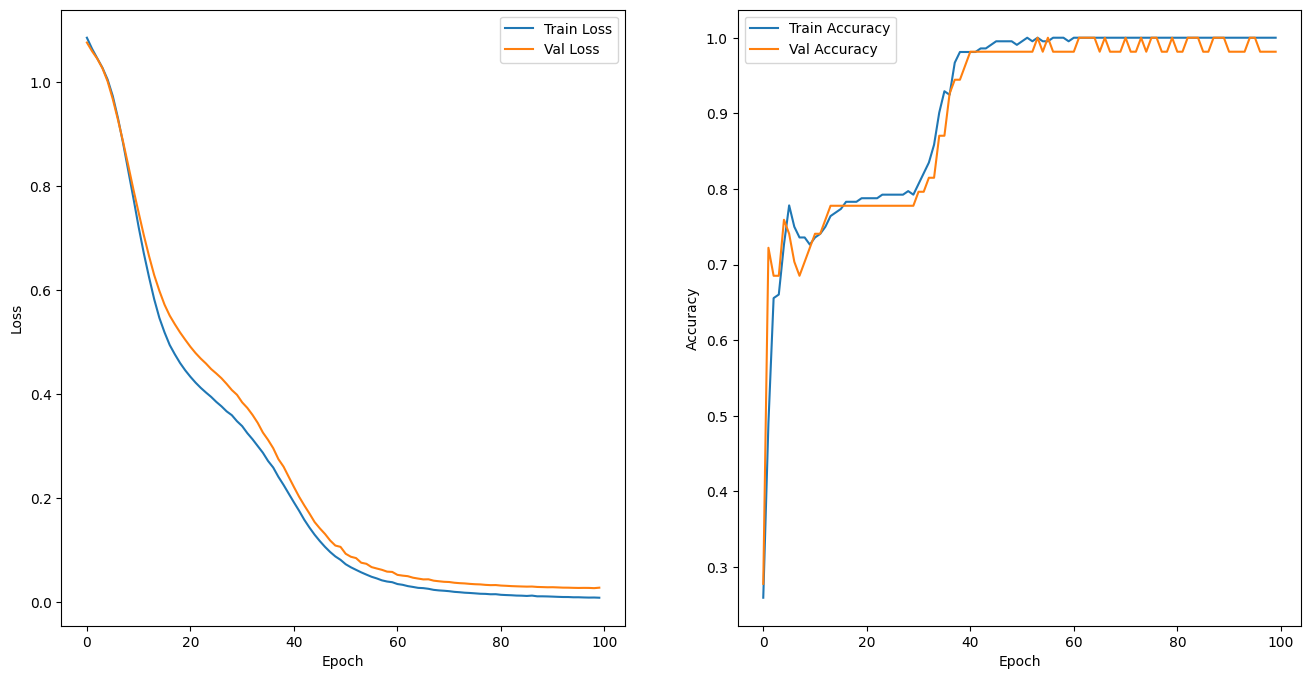

In [27]:
plot_history(history)

In [28]:
df = X_test[['bill_length_mm','bill_depth_mm',
'flipper_length_mm', 'body_mass_g']]
df.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
30,39.5,16.7,178.0,3250.0
317,46.9,14.6,222.0,4875.0
79,42.1,19.1,195.0,4000.0
201,49.8,17.3,198.0,3675.0
63,41.1,18.2,192.0,4050.0


In [29]:
df_s = scaler.transform(df)
df_s[:10]

array([[0.26909091, 0.42857143, 0.10169492, 0.15277778],
       [0.53818182, 0.17857143, 0.84745763, 0.60416667],
       [0.36363636, 0.71428571, 0.38983051, 0.36111111],
       [0.64363636, 0.5       , 0.44067797, 0.27083333],
       [0.32727273, 0.60714286, 0.33898305, 0.375     ],
       [0.46545455, 0.08333333, 0.6779661 , 0.56944444],
       [0.67636364, 0.22619048, 0.86440678, 0.79166667],
       [0.64      , 0.6547619 , 0.38983051, 0.25      ],
       [0.63636364, 0.60714286, 0.3559322 , 0.29861111],
       [0.70181818, 0.70238095, 0.49152542, 0.34722222]])

In [30]:
dfX = pd.DataFrame(df_s, columns=['bill_length_mm','bill_depth_mm',
'flipper_length_mm', 'body_mass_g'])
dfX.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.269091,0.428571,0.101695,0.152778
1,0.538182,0.178571,0.847458,0.604167
2,0.363636,0.714286,0.389831,0.361111
3,0.643636,0.500000,0.440678,0.270833
4,0.327273,0.607143,0.338983,0.375000


In [31]:
dfX['island']= X_test['island'].map(
{'Biscoe': 0, 'Dream': 1, 'Torgersen': 2}).reset_index(drop = True)
dfX['sex'] = X_test['sex'].map(
{'FEMALE': 0, 'MALE': 1}).reset_index(drop = True)
dfX.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island,sex
0,0.269091,0.428571,0.101695,0.152778,1,0
1,0.538182,0.178571,0.847458,0.604167,0,0
2,0.363636,0.714286,0.389831,0.361111,2,1
3,0.643636,0.500000,0.440678,0.270833,1,0
4,0.327273,0.607143,0.338983,0.375000,0,1
5,0.465455,0.083333,0.677966,0.569444,0,0
6,0.676364,0.226190,0.864407,0.791667,0,1
7,0.640000,0.654762,0.389831,0.250000,1,1
8,0.636364,0.607143,0.355932,0.298611,1,1
9,0.701818,0.702381,0.491525,0.347222,1,1


In [32]:
dfy = y_test.map(
{'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}).reset_index(drop = True)
dfy

,species
0,0
1,2
2,0
3,1
4,0
...,...
62,2
63,0
64,0
65,2


In [33]:
X_test = dfX.values
y_test = dfy.values
X_test = X_test.astype('float32')

In [34]:
y_pred = model.predict(X_test)
y_pred[:5]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


array([[8.77557278e-01, 1.22429356e-01, 1.32478044e-05],
       [1.50670996e-08, 7.19476026e-04, 9.99280512e-01],
       [9.99566674e-01, 4.33414971e-04, 1.07106424e-11],
       [1.00619334e-04, 9.87780750e-01, 1.21187000e-02],
       [9.98856723e-01, 1.09024753e-03, 5.31334299e-05]], dtype=float32)

In [36]:
import numpy as np

y_pred = np.argmax(y_pred, axis=1)
y_pred[:10]

array([0, 2, 0, 1, 0, 2, 2, 1, 1, 1])

In [37]:
from sklearn.metrics import confusion_matrix
cf_matrix = confusion_matrix(y_test, y_pred)
print(cf_matrix)

[[31  0  0]
 [ 0 13  0]
 [ 0  0 23]]


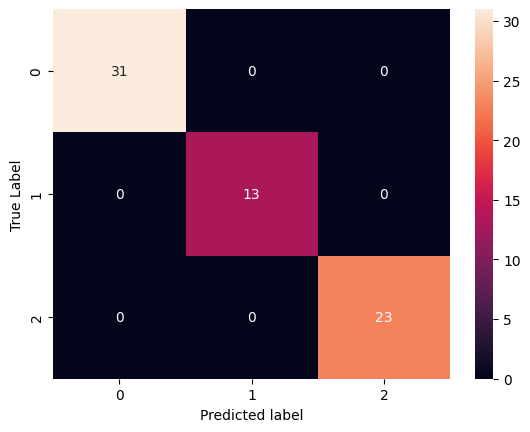

In [38]:
import seaborn as sns
sns.heatmap(cf_matrix, annot=True)
plt.ylabel('True Label')
plt.xlabel('Predicted label')
plt.show()

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score
def print_scores(y_true, y_pred):
  print('accuracy_score: {0:.4f}'.format(
    accuracy_score(y_true, y_pred)))
  print('precision_score: {0:.4f}'.format(
    precision_score(y_true, y_pred, average='macro')))
  print('recall_score: {0:.4f}'.format(
    recall_score(y_true, y_pred, average='macro')))
print_scores(y_test, y_pred)

accuracy_score: 1.0000
precision_score: 1.0000
recall_score: 1.0000
